In [1]:
import numpy as np
import pyat.readwrite as at
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp

In [2]:
%reload_ext pyat.readwrite

In [3]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [4]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

In [131]:
data1 = scipy.io.loadmat("field_values20260707/field_values20260707.mat")

f = data1['f'].squeeze()
f_Vg = f[1:-1]
c = data1['soundspeed'].squeeze()
Vg = data1['Vg'].squeeze()
receiver_range = data1['range'][0,0]

nmodes, nspeed, nfreq = Vg.shape

In [132]:
arrival_times_data = receiver_range/Vg[:, c == TRUE_SOUNDSPEED, ...]
arrival_times_replica = receiver_range/Vg

array([[[0.00679941, 0.00679936, 0.00679936, ..., 0.0068467 ,
         0.00684689, 0.00684726]],

       [[0.00681824, 0.00681805, 0.00681786, ..., 0.00679414,
         0.00679414, 0.00679414]],

       [[0.00684821, 0.00684774, 0.00684726, ..., 0.00679945,
         0.00679964, 0.00679964]],

       ...,

       [[0.0083796 , 0.0083518 , 0.0083241 , ..., 0.0070368 ,
         0.00703585, 0.00703453]],

       [[0.00880113, 0.00876878, 0.00873709, ..., 0.00707152,
         0.00707019, 0.00706849]],

       [[0.00926786, 0.00922673, 0.0091867 , ..., 0.00710814,
         0.00710681, 0.00710454]]], shape=(17, 1, 299))

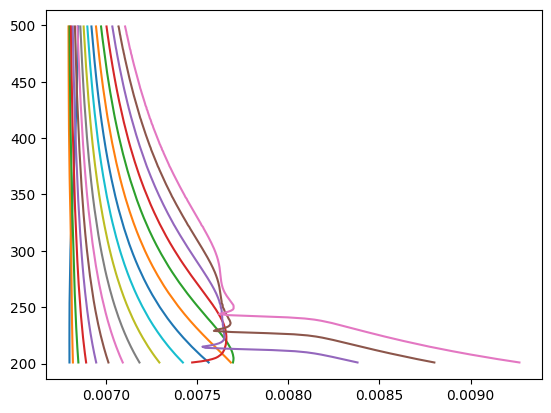

In [133]:
fig, ax = plt.subplots()

ax.plot(arrival_times_data.squeeze().T, f_Vg)

arrival_times_data

In [ ]:
residuals_direct = arrival_times_data - Vg

In [145]:
residual_intramodal = np.zeros((nspeed, nmodes, nfreq, nfreq))

for indmode in range(nmodes):
    delta_data = arrival_times_data[indmode,...] - arrival_times_data[indmode,...].T
    for indc in range(nspeed): 
        delta_replica = arrival_times_replica[indmode, indc] - arrival_times_replica[indmode, indc, :, np.newaxis]
        residual_intramodal[indc, indmode, ...] = np.abs(delta_data - delta_replica)**2
        
likelihood_intramodal = np.exp(-residual_intramodal.sum(1)/1e-7)

In [122]:
residual_intermodal = np.zeros((nspeed, nfreq, nmodes, nmodes))

for indfreq in range(nfreq):
    delta_data = arrival_times_data[...,indfreq].T - arrival_times_data[...,indfreq]
    for indc in range(nspeed): 
        delta_replica = arrival_times_replica[:, indc, indfreq] - arrival_times_replica[:, np.newaxis, indc, indfreq]
        residual_intermodal[indc, indfreq, ...] = np.abs(delta_data - delta_replica)**2
        
likelihood_intermodal = np.exp(-residual_intermodal.sum(1)/1e-7)

Text(0.02, 0.5, 'Likelihood ($\\exp (-e_2/\\sigma)$)')

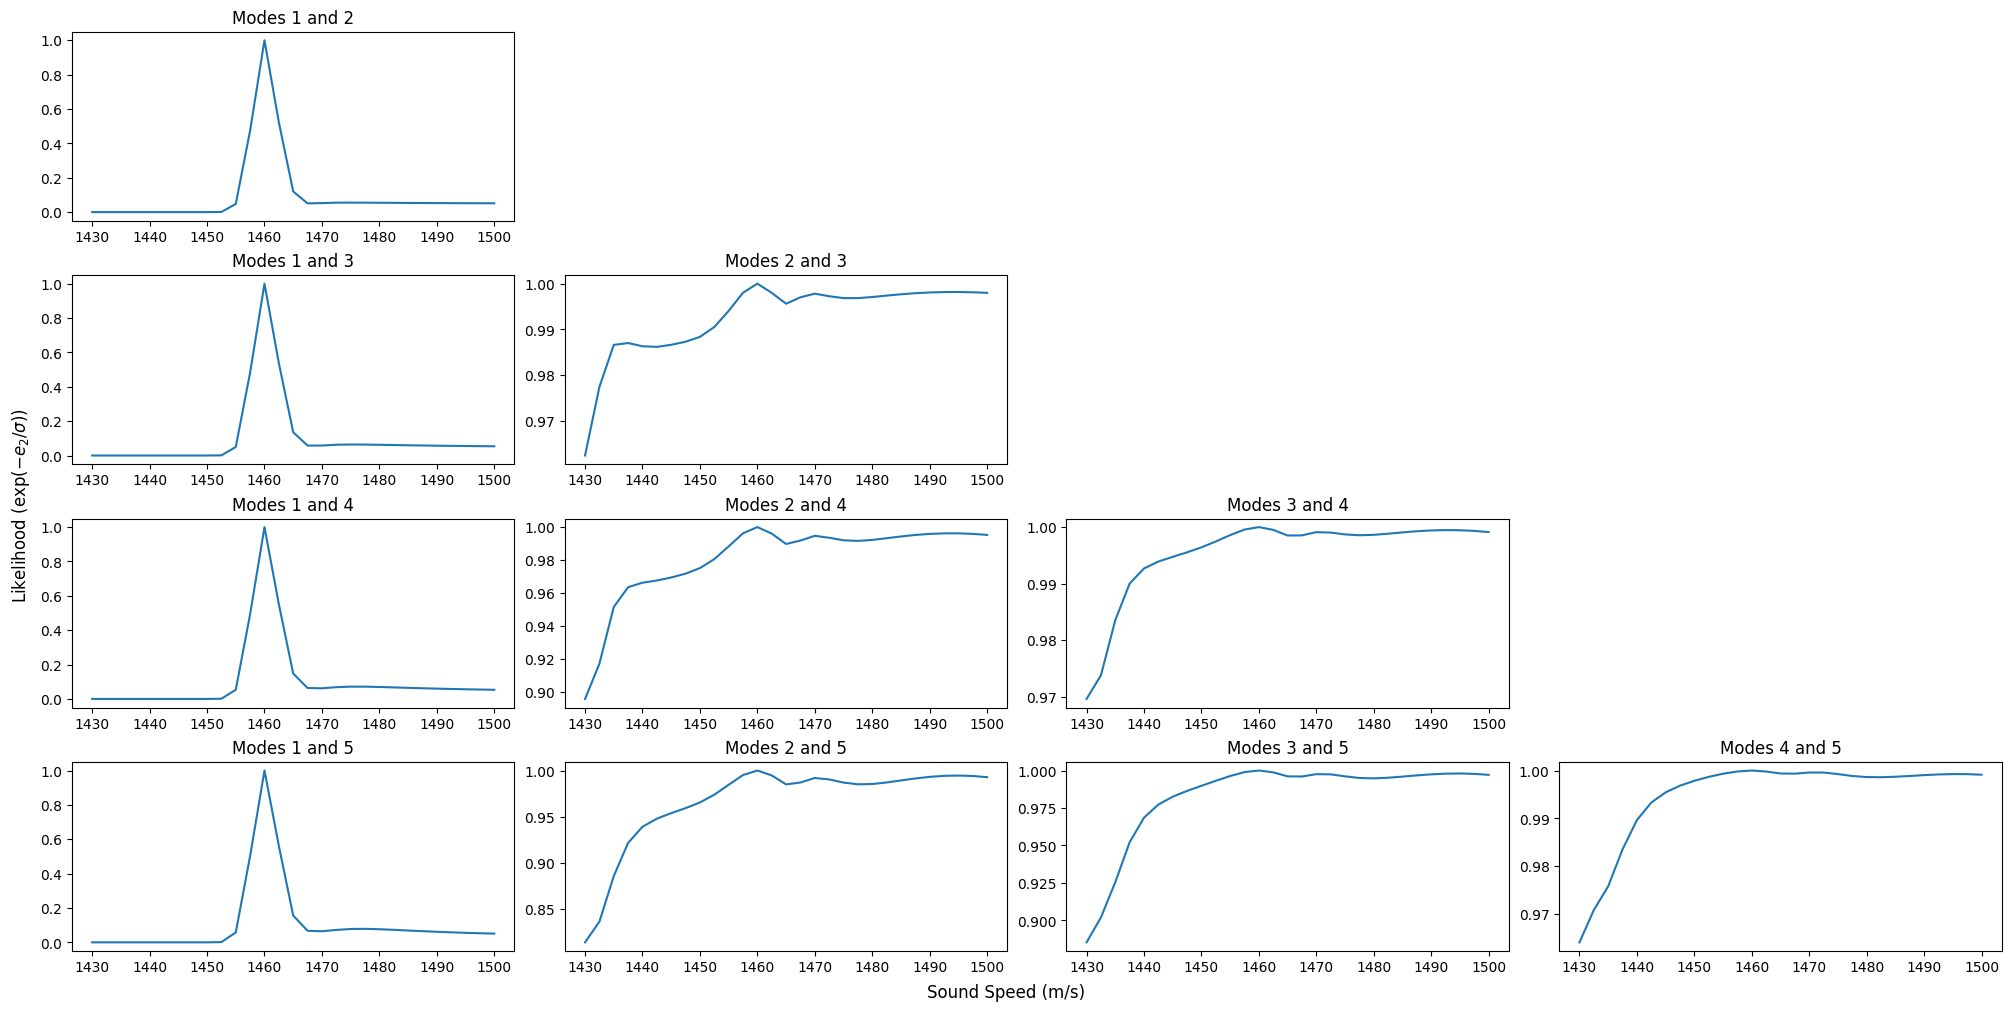

In [173]:
fig = plt.figure(layout='constrained')

for ir in range(4):
    for ic in range(ir+1):
        ax = fig.add_subplot(4,4, 4*ir + ic +1)
        ax.plot(c, likelihood_intermodal[:, ir+1, ic])

        ax.set_title(f'Modes {ic+1} and {ir+2}')

fig.set_size_inches([20,10])
fig.supxlabel('Sound Speed (m/s)')
fig.supylabel('Likelihood ($\\exp (-e_2/\\sigma)$)')

In [174]:
fig.savefig('Likelihood Intermodal.png', dpi=600)

In [151]:
likelihood_intramodal.shape

(29, 299, 299)

NameError: name 'true_soundspeed' is not defined

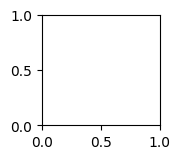

In [152]:
soundspeed_est_intramodal = c[np.argmax(likelihood_intramodal, 0)]

fig = plt.figure(layout='constrained')

for imode in range(nmodes):
    row, col = np.unravel_index(imode, (4,5))
    ax = fig.add_subplot(4,5,imode+1)
    ax.pcolormesh(f_Vg, f_Vg, np.abs(soundspeed_est_intramodal[imode] - true_soundspeed))
    #ax.pcolormesh(f_Vg, f_Vg, likelihood_intramodal[imode])
    ax.set_title(f'Mode {imode+1}')

fig.set_size_inches([10, 8])

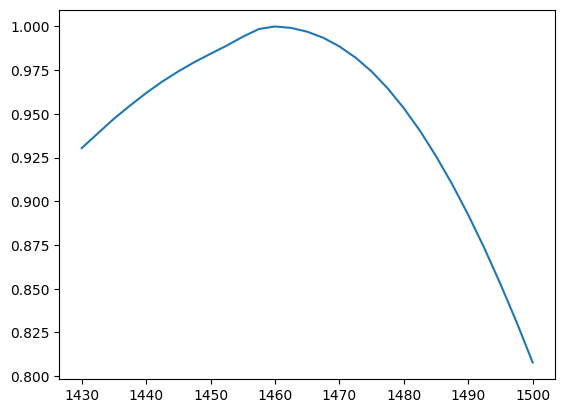

In [148]:
plt.plot(c, likelihood_intramodal[..., f_Vg==250, f_Vg==300].sum(1))